<a href="https://colab.research.google.com/github/Jana-Alothman/GP1/blob/main/Arabic_Readability_Classification_On_BAREC_Corpus_Using_Temp_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Arabic Readability Classification On BAREC Corpus Using Decision Tree Model**

This notebook presents the implementation of a **Decision Tree classifier** for Arabic readability classification using the BAREC Corpus.

The experiments use TF-IDF features extracted from Arabic text and evaluate the model under two readability classification schemes: **19-level** and **5-level**.

For each task:
1. A baseline Decision Tree is trained using **only scikit-learn default hyperparameters**.
2. Hyperparameters are tuned using **GridSearchCV with 5-fold cross-validation and accuracy scoring**.
3. The best hyperparameters found by GridSearchCV are used to train two tuned models:
   - `class_weight="balanced"`
   - `class_weight=None`
4. The baseline and tuned models are evaluated using the same evaluation functions and metrics.

# **Data Collection**

**Dataset Source:**

In this project, the dataset used for Arabic readability assessment was obtained from BAREC Corpus v1.0 on Hugging Face.

---
**Research paper:**

A Large and Balanced Corpus for Fine-grained Arabic Readability Assessment.

---

**Data Fields:**
- ID: Unique sentence identifier.
- Sentence: The sentence text.
- Word_Count: Number of words in the sentence.
- Word: Simply tokenized and dediacritized sentences.
- Lex: Each word is replaced by its predicited lemma (dediacritized).
- D3Tok: We tokenize words into their base and clitics forms.
- D3Lex: We replace the base forms in D3Tok with the predicited lemmas.
- Readability_Level: The readability level in 19-levels scheme, ranging from 1-alif to 19-qaf.
- Readability_Level_19: The readability level in 19-levels scheme, ranging from 1 to 19.
- Readability_Level_7: The readability level in 7-levels scheme, ranging from 1 to 7.
- Readability_Level_5: The readability level in 5-levels scheme, ranging from 1 to 5.
- Readability_Level_3: The readability level in 3-levels scheme, ranging from 1 to 3.
- Annotator: The annotator ID (A1-A5 or IAA).
- Document: Source document file name.
- Source: Document source.
- Book: Book name.
- Author: Author name.
- Domain: Domain (Arts & Humanities, STEM or Social Sciences).
- Text_Class: Readership group (Foundational, Advanced or Specialized).

---
**Supported Tasks:**

The dataset supports multi-class readability classification in the following formats:

- 19 levels (default)
- 7 levels
- 5 levels
- 3 levels

---
**Data Splits:**
- The BAREC dataset has three splits: Train (80%), Dev (10%), and Test (10%).
- The splits are in the document level.
- The splits are balanced accross Readability Levels, Domains, and Text Classes.



In [1]:
# Install required libraries for dataset loading and processing.

!pip install datasets pandas

In [2]:
# Load the BAREC dataset and display dataset splits and columns.

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("CAMeL-Lab/BAREC-Corpus-v1.0")

# Load each split separately
train_df = dataset["train"].to_pandas()
dev_df = dataset["dev"].to_pandas()
test_df = dataset["test"].to_pandas()
full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)

# Display split sizes
print("Train Shape:", train_df.shape)
print("Validation Shape:", dev_df.shape)
print("Test Shape:", test_df.shape)
print("Full Dataset Shape:", full_df.shape)

print("\nDataset Columns:\n")
print(full_df.columns)

print("\nSample Data:\n")
full_df.head()

README.md:   0%|          | 0.00/6.19k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.9MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/dev-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.37MB            

data/dev-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/54845 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/7310 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7286 [00:00<?, ? examples/s]

Train Shape: (54845, 19)
Validation Shape: (7310, 19)
Test Shape: (7286, 19)
Full Dataset Shape: (69441, 19)

Dataset Columns:

Index(['ID', 'Sentence', 'Word_Count', 'Word', 'Lex', 'D3Tok', 'D3Lex',
       'Readability_Level', 'Readability_Level_19', 'Readability_Level_7',
       'Readability_Level_5', 'Readability_Level_3', 'Annotator', 'Document',
       'Source', 'Book', 'Author', 'Domain', 'Text_Class'],
      dtype='object')

Sample Data:



,ID,Sentence,Word_Count,Word,Lex,D3Tok,D3Lex,Readability_Level,Readability_Level_19,Readability_Level_7,Readability_Level_5,Readability_Level_3,Annotator,Document,Source,Book,Author,Domain,Text_Class
0,10100290001,مجلة كل الأولاد وكل البنات,5,مجلة كل الأولاد وكل البنات,مجلة كل ولد كل بنت,مجلة كل ال+ أولاد و+ كل ال+ بنات,مجلة كل ال+ ولد و+ كل ال+ بنت,7-zay,7,2,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
1,10100290002,ماجد,1,ماجد,ماجد,ماجد,ماجد,1-alif,1,1,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
2,10100290003,الأربعاء 21 يناير 1987,4,الأربعاء 21 يناير 1987,أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,8-Ha,8,3,2,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
3,10100290004,الموافق 21 جمادى الأول 1407هــ,6,الموافق 21 جمادى الأول 1407ه,موافق 21 جمادى أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,7-zay,7,2,1,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
4,10100290005,السنة الثامنة,2,السنة الثامنة,سنة ثامن,ال+ سنة ال+ ثامنة,ال+ سنة ال+ ثامن,5-ha,5,2,1,1,A4,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational


In [3]:
# Save the complete dataset as a CSV file.

full_df.to_csv("BAREC_full.csv", index=False)

In [4]:
# Create a filtered version containing selected columns only.

filtered_full_df = full_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_train_df = train_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_dev_df = dev_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_test_df = test_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_full_df.to_csv("BAREC_full_filtered.csv", index=False)
filtered_full_df.head()

,Word,Word_Count,Domain,Text_Class,Readability_Level_19,Readability_Level_5
0,مجلة كل الأولاد وكل البنات,5,Arts & Humanities,Foundational,7,1
1,ماجد,1,Arts & Humanities,Foundational,1,1
2,الأربعاء 21 يناير 1987,4,Arts & Humanities,Foundational,8,2
3,الموافق 21 جمادى الأول 1407ه,6,Arts & Humanities,Foundational,7,1
4,السنة الثامنة,2,Arts & Humanities,Foundational,5,1


**Feature Selection Justification**

Only the **Word** column was used as the input feature because this study aims to classify readability using textual information represented by TF-IDF features.

The remaining columns were excluded for the following reasons:

---

**Text Variations (Sentence, Lex, D3Tok, D3Lex)**

These columns are different linguistic transformations of the same sentence.

- They represent the same original text in different formats  

---

**Alternative Readability Levels (3, 7-level schemes)**

These columns represent the same target variable (readability) but on different scales.

- They contain overlapping information with the main target (19 & 5 -level scales)


---

**Metadata Columns (ID, Annotator, Document, Source, Book, Author)**

These columns are not useful for prediction.

- They are administrative or contextual only
- They do not contribute to readability prediction

---

**Final Selected Features**

The final dataset used for modeling includes:

- **Word** → main input text
- **Word_Count** → length-based feature
- **Domain** → topic/category information
- **Text_Class** → readership group
- **Readability_Level_19** → target label
- **Readability_Level_5** → target label

In [5]:
# Download both the full and filtered datasets.

from google.colab import files

#files.download("BAREC_full.csv")
#files.download("BAREC_full_filtered.csv")

# **Data Preprocessing**

In this stage, we perform preprocessing on the **filtered dataset** to ensure it is clean, consistent, and ready for machine learning.

## 1. Checking Missing Values

We first check whether the dataset contains any missing values.

Even if the dataset is clean, this step ensures there are no hidden nulls that could affect model training.

In [6]:
filtered_full_df.isnull().sum()

,0
Word,0
Word_Count,0
Domain,0
Text_Class,0
Readability_Level_19,0
Readability_Level_5,0


**Interpretation:** The dataset shows no missing values across all selected features, indicating that the data is complete and well-structured.

## 2. Checking Duplicate Rows

We check for duplicate rows to make sure the model does not learn repeated examples that could bias training.

In [7]:
beforeFull = filtered_full_df.duplicated().sum()
beforeTrain = filtered_train_df.duplicated().sum()
beforeDev = filtered_dev_df.duplicated().sum()
beforeTest = filtered_test_df.duplicated().sum()

print("Before dropping duplicates (Full) = " , beforeFull)
print("Before dropping duplicates (Train) = " , beforeTrain)
print("Before dropping duplicates (Dev) = " , beforeDev)
print("Before dropping duplicates (Test) = " , beforeTest)

Before dropping duplicates (Full) =  3542
Before dropping duplicates (Train) =  2670
Before dropping duplicates (Dev) =  195
Before dropping duplicates (Test) =  213


In [8]:
afterFull = filtered_full_df.drop_duplicates().duplicated().sum()
afterTrain = filtered_train_df.drop_duplicates().duplicated().sum()
afterDev = filtered_dev_df.drop_duplicates().duplicated().sum()
afterTest = filtered_test_df.drop_duplicates().duplicated().sum()

print("After dropping duplicates (Full) = " , afterFull)
print("After dropping duplicates (Train) = " , afterTrain)
print("After dropping duplicates (Dev) = " , afterDev)
print("After dropping duplicates (Test) = " , afterTest)

After dropping duplicates (Full) =  0
After dropping duplicates (Train) =  0
After dropping duplicates (Dev) =  0
After dropping duplicates (Test) =  0


**Interpretation:** 3,542 duplicate rows were found in the dataset, indicating repeated samples. These duplicates were removed to prevent bias and ensure the model does not learn from repeated instances of the same data.

## 3. Checking Label Distribution

We analyze the distribution of the 19-level and 5-level readability classes to understand whether the dataset is balanced or imbalanced.

In [9]:
filtered_full_df["Readability_Level_19"].value_counts().sort_index()

,count
Readability_Level_19,
1,409
2,437
3,1462
4,751
5,3443
6,1534
7,5438
8,5683
9,2023


In [10]:
filtered_full_df["Readability_Level_5"].value_counts().sort_index()

,count
Readability_Level_5,
1,13474
2,22383
3,18510
4,13234
5,1840


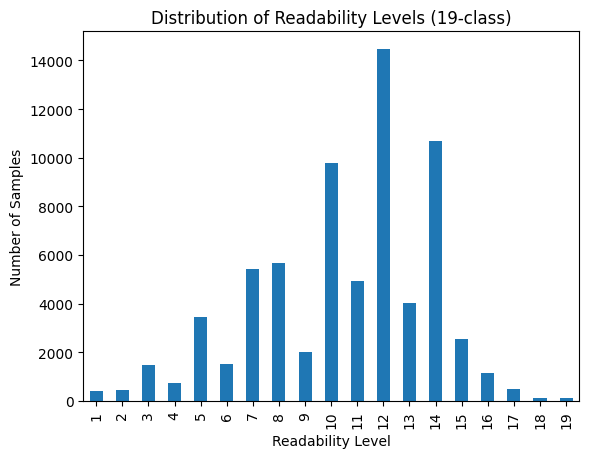

In [11]:
import matplotlib.pyplot as plt

full_df["Readability_Level_19"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (19-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

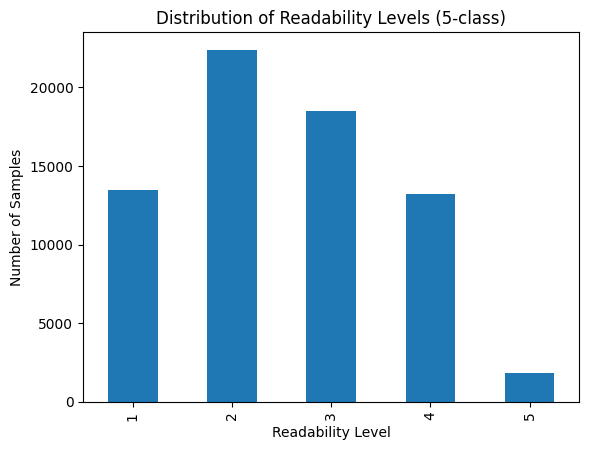

In [12]:
import matplotlib.pyplot as plt

full_df["Readability_Level_5"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (5-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

**Interpretation:** The dataset shows a clear class imbalance across the 19 and 5 readability levels. Some classes contain a significantly higher number of samples, while higher levels have very few instances. This imbalance may affect model performance and bias predictions toward majority classes.

#**Model Training**

## **Decision Tree Model**

### Why Decision Tree?

A Decision Tree is a supervised machine-learning algorithm that learns a sequence of feature-based decision rules to assign each sample to a class.

For this project, TF-IDF converts the Arabic text into numerical features, and the Decision Tree learns which textual features are useful for separating the readability levels.

Decision Trees were selected because they:
- can model non-linear decision boundaries,
- do not require feature scaling,
- support multi-class classification directly,
- provide interpretable rule-based decisions,
- and support `class_weight`, allowing us to study the effect of class imbalance.

Because text represented with TF-IDF is high-dimensional, an unrestricted Decision Tree can overfit. Therefore, the baseline is kept completely default as required, while `max_depth`, `min_samples_split`, and `min_samples_leaf` are tuned using cross-validation.

### **Decision Tree Setup and Hyperparameter Search Space**

The same hyperparameter search space is used for both the **19-level** and **5-level** experiments.

`class_weight` is intentionally **not included** in the GridSearchCV search space. GridSearchCV first identifies the best structural Decision Tree hyperparameters. The exact same selected structural parameters are then used to compare:
- `class_weight="balanced"`
- `class_weight=None`

This gives a fair comparison of the effect of class weighting without changing the tree structure between the two tuned variants.

The search space is:

- `criterion`: `gini` and `entropy`  
  These are the two standard impurity measures used to choose splits.

- `max_depth`: `None`, `10`, `20`, `30`  
  `None` allows the tree to grow without a depth restriction, while 10, 20, and 30 test progressively more flexible trees and help control overfitting.

- `min_samples_split`: `2`, `5`, `10`  
  The default value 2 is retained as a reference, while larger values regularize the model by requiring more samples before creating a new split.

- `min_samples_leaf`: `1`, `2`, `4`  
  The default value 1 is retained, while larger values prevent leaves from being formed from very small numbers of training samples.

This produces **72 combinations** and, with 5-fold cross-validation, **360 fits per readability task**.

In [13]:
# Import TF-IDF vectorizer for converting text into numerical feature vectors
from sklearn.feature_extraction.text import TfidfVectorizer

# Define input text
dt_X_train = filtered_train_df["Word"]
dt_X_dev = filtered_dev_df["Word"]
dt_X_test = filtered_test_df["Word"]

# Create TF-IDF features using unigrams and bigrams
dt_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2)
)

# Fit TF-IDF only on the training set, then transform dev and test
dt_X_train_tfidf = dt_vectorizer.fit_transform(dt_X_train)
dt_X_dev_tfidf = dt_vectorizer.transform(dt_X_dev)
dt_X_test_tfidf = dt_vectorizer.transform(dt_X_test)

print("Train TF-IDF shape:", dt_X_train_tfidf.shape)
print("Dev TF-IDF shape:", dt_X_dev_tfidf.shape)
print("Test TF-IDF shape:", dt_X_test_tfidf.shape)

Train TF-IDF shape: (54845, 520826)
Dev TF-IDF shape: (7310, 520826)
Test TF-IDF shape: (7286, 520826)


**ngram_range Justification**


The parameter `ngram_range=(1,2)` was selected to include both **unigrams** (single words) and **bigrams** (pairs of consecutive words). While unigrams capture the importance of individual words, bigrams preserve short contextual information that may improve the model's ability to distinguish different readability levels.

This configuration is widely adopted in text classification tasks because it provides a good balance between capturing contextual information and maintaining computational efficiency.

---

##**Model Evaluation Function**

**Evaluation Metrics Overview:**

The model is evaluated using multiple metrics to properly reflect its performance on an ordinal readability classification task.

- **Quadratic Weighted Kappa (QWK):** Primary metric that measures agreement between predicted and actual labels while penalizing larger errors more heavily.
- **Accuracy:** Measures exact match between predicted and true labels.
- **Acc ±1:** Considers predictions correct if they are within one level of the true label.
- **Macro F1-score:** Evaluates performance equally across all classes, making it suitable for imbalanced datasets.
- **Precision & Recall:** Measure class-level prediction quality and coverage.
- **Confusion Matrix:** Provides detailed insight into misclassification patterns.
- **MAE/Distance (Mean Absolute Error)**: The average absolute difference between predicted and true values. Treats all errors equally. Lower is better.
- **RMSE (Root Mean Square Error):** The square root of the average squared difference between predicted and true values. Penalizes large errors more heavily than MAE. Lower is better.
- **R² Score:** Indicates how well predictions explain variance in readability levels, though less common for classification tasks.

In [14]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    mean_absolute_error,
    mean_squared_error,
    classification_report,
    cohen_kappa_score,
    r2_score
)

import numpy as np


def evaluate_dt_model(y_true, y_pred, dataset_name):
    """Evaluate a Decision Tree model using the project evaluation metrics."""

    accuracy = accuracy_score(y_true, y_pred)
    adj_accuracy = np.mean(np.abs(y_true - y_pred) <= 1)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print("=" * 60)
    print(dataset_name)
    print("=" * 60)

    print(f"Accuracy:                      {accuracy:.4f}")
    print(f"Adjacent Accuracy (±1):        {adj_accuracy:.4f}")
    print(f"Quadratic Weighted Kappa:      {qwk:.4f}")
    print(f"Macro F1-score:                {macro_f1:.4f}")
    print(f"Weighted Precision:            {precision:.4f}")
    print(f"Weighted Recall:               {recall:.4f}")
    print(f"Mean Absolute Error (MAE):     {mae:.4f}")
    print(f"Root Mean Squared Error:       {rmse:.4f}")
    print(f"R² Score:                      {r2:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, zero_division=0))

**How to call the function?**

```python
evaluate_dt_model(
    dt_y_test_19,
    dt_baseline_19_test_pred,
    "Baseline Decision Tree (19-Level) - Test Set"
)
```

##**Confusion Matrix Function**

In [15]:
# Import libraries for confusion matrix visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels, title):
    """
    Plot a confusion matrix for a classification model.
    """

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.show()

**How to call the function?**

```python
plot_confusion_matrix(
    dt_y_test_19,
    dt_baseline_19_test_pred,
    labels=list(range(1, 20)),
    title="Confusion Matrix - Baseline Decision Tree (19-Level)"
)
```

---

## **Decision Tree Baseline Model (19-Level)**

In [16]:
# Define target labels for the 19-level classification task
dt_y_train_19 = filtered_train_df["Readability_Level_19"]
dt_y_dev_19 = filtered_dev_df["Readability_Level_19"]
dt_y_test_19 = filtered_test_df["Readability_Level_19"]

In [17]:
from sklearn.tree import DecisionTreeClassifier

# Baseline model: all DecisionTreeClassifier hyperparameters remain at their defaults
dt_baseline_19 = DecisionTreeClassifier()

print(dt_baseline_19.get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


In [18]:
# Train the baseline model
dt_baseline_19.fit(
    dt_X_train_tfidf,
    dt_y_train_19
)

DecisionTreeClassifier()

In [19]:
# Generate test predictions
dt_baseline_19_test_pred = dt_baseline_19.predict(dt_X_test_tfidf)

In [20]:
evaluate_dt_model(
    dt_y_test_19,
    dt_baseline_19_test_pred,
    "Baseline Decision Tree (19-Level) - Test Set"
)

Baseline Decision Tree (19-Level) - Test Set
Accuracy:                      0.2774
Adjacent Accuracy (±1):        0.4182
Quadratic Weighted Kappa:      0.3231
Macro F1-score:                0.2185
Weighted Precision:            0.2752
Weighted Recall:               0.2774
Mean Absolute Error (MAE):     2.6222
Root Mean Squared Error:       3.7273
R² Score:                      -0.3072

Classification Report:

              precision    recall  f1-score   support

           1       0.65      0.53      0.59        32
           2       0.31      0.25      0.28        36
           3       0.36      0.37      0.36       141
           4       0.12      0.28      0.17        86
           5       0.36      0.42      0.39       380
           6       0.20      0.20      0.20       139
           7       0.30      0.42      0.35       585
           8       0.25      0.41      0.31       541
           9       0.36      0.36      0.36       190
          10       0.31      0.46      0.37   

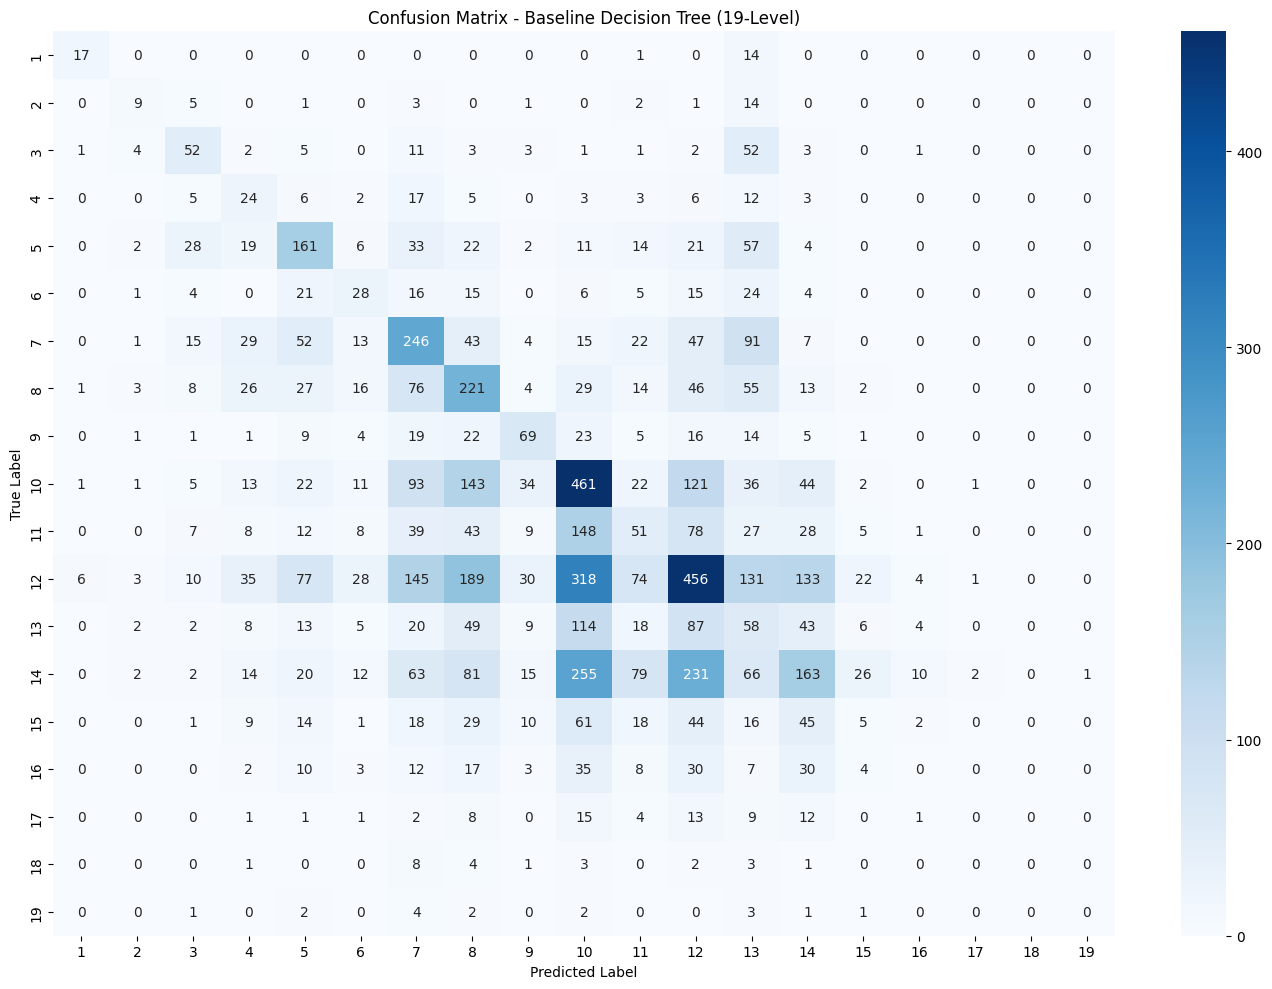

In [21]:
plot_confusion_matrix(
    dt_y_test_19,
    dt_baseline_19_test_pred,
    labels=list(range(1, 20)),
    title="Confusion Matrix - Baseline Decision Tree (19-Level)"
)

### **Decision Tree Baseline Findings (19-Level)**

The baseline Decision Tree achieved an accuracy of 27.77%, with an adjacent accuracy of 41.82%. The model obtained a QWK of 0.3257 and a Macro F1-score of 0.2188. The MAE of 2.6061 indicates that predictions differed from the true readability level by approximately 2.6 levels on average.

Overall, the baseline provides a useful reference point, but its performance shows difficulty in consistently distinguishing between the 19 readability levels.classification report and confusion matrix.

The interpretation should be based on the actual generated results rather than inserting estimated values.

## **Decision Tree Hyperparameter Tuning Using GridSearchCV (19-Level)**

### Hyperparameter Search Space

GridSearchCV was used to identify the best Decision Tree hyperparameters using 5-fold cross-validation. The search focused on parameters that control the splitting strategy and tree complexity:

criterion: ["gini", "entropy"]
max_depth: [None, 10, 20, 30]
min_samples_split: [2, 5, 10]
min_samples_leaf: [1, 2, 4]

These values allow the search to compare the default Decision Tree settings with more restricted tree structures that may reduce overfitting. The best model was selected based on classification accuracy.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Same parameter grid used for both 19-level and 5-level experiments
dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Base estimator used by GridSearchCV
dt_base = DecisionTreeClassifier()

# Required GridSearchCV configuration
dt_grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=dt_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

# Search using the TRAINING SET ONLY
dt_grid_search.fit(
    dt_X_train_tfidf,
    dt_y_train_19
)

# Save the 19-level best parameters before reusing dt_grid_search for the 5-level task
dt_best_params_19 = dt_grid_search.best_params_.copy()
dt_best_cv_accuracy_19 = dt_grid_search.best_score_

print("Best Parameters (19-Level):", dt_best_params_19)
print(f"Best 5-Fold CV Accuracy (19-Level): {dt_best_cv_accuracy_19:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits


## **Decision Tree Tuned Model (19-Level)**
### `class_weight="balanced"`

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Use exactly the best structural parameters found by GridSearchCV
dt_tuned_balanced_19 = DecisionTreeClassifier(
    **dt_best_params_19,
    class_weight="balanced"
)

dt_tuned_balanced_19.fit(
    dt_X_train_tfidf,
    dt_y_train_19
)

dt_tuned_balanced_19_test_pred = dt_tuned_balanced_19.predict(dt_X_test_tfidf)

evaluate_dt_model(
    dt_y_test_19,
    dt_tuned_balanced_19_test_pred,
    "Tuned Decision Tree - Balanced (19-Level) - Test Set"
)

plot_confusion_matrix(
    dt_y_test_19,
    dt_tuned_balanced_19_test_pred,
    labels=list(range(1, 20)),
    title="Confusion Matrix - Tuned Decision Tree Balanced (19-Level)"
)

### **Decision Tree Tuned Findings (19-Level)**
#### `class_weight="balanced"`

After running the model, compare its results with the baseline and the unbalanced tuned model.

Focus especially on whether balancing:
- improves Macro F1 or recall for minority readability levels,
- changes exact Accuracy,
- changes QWK and Adjacent Accuracy,
- and reduces majority-class bias in the confusion matrix.

Use the generated values only.

## **Decision Tree Tuned Model (19-Level)**
### `class_weight=None`

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Same best structural parameters; only class_weight changes
dt_tuned_none_19 = DecisionTreeClassifier(
    **dt_best_params_19,
    class_weight=None
)

dt_tuned_none_19.fit(
    dt_X_train_tfidf,
    dt_y_train_19
)

dt_tuned_none_19_test_pred = dt_tuned_none_19.predict(dt_X_test_tfidf)

evaluate_dt_model(
    dt_y_test_19,
    dt_tuned_none_19_test_pred,
    "Tuned Decision Tree - None Class Weight (19-Level) - Test Set"
)

plot_confusion_matrix(
    dt_y_test_19,
    dt_tuned_none_19_test_pred,
    labels=list(range(1, 20)),
    title="Confusion Matrix - Tuned Decision Tree None Class Weight (19-Level)"
)

### **Decision Tree Tuned Findings (19-Level)**
#### `class_weight=None`

After running the model, compare it with:
1. the fully default baseline, and
2. the tuned balanced model.

Because the structural hyperparameters are identical in both tuned models, any performance difference between the two tuned variants can be attributed to the effect of `class_weight`.

---

## **Decision Tree Baseline Model (5-Level)**

In [ ]:
# Define target labels for the 5-level classification task
dt_y_train_5 = filtered_train_df["Readability_Level_5"]
dt_y_dev_5 = filtered_dev_df["Readability_Level_5"]
dt_y_test_5 = filtered_test_df["Readability_Level_5"]

# Fully default baseline
dt_baseline_5 = DecisionTreeClassifier()

print(dt_baseline_5.get_params())

dt_baseline_5.fit(
    dt_X_train_tfidf,
    dt_y_train_5
)

dt_baseline_5_test_pred = dt_baseline_5.predict(dt_X_test_tfidf)

evaluate_dt_model(
    dt_y_test_5,
    dt_baseline_5_test_pred,
    "Baseline Decision Tree (5-Level) - Test Set"
)

plot_confusion_matrix(
    dt_y_test_5,
    dt_baseline_5_test_pred,
    labels=list(range(1, 6)),
    title="Confusion Matrix - Baseline Decision Tree (5-Level)"
)

### **Decision Tree Baseline Findings (5-Level)**

Run the baseline and interpret the actual output. Compare the 5-level results with the 19-level baseline, while remembering that direct accuracy comparisons are affected by the different number of classes.

## **Decision Tree Hyperparameter Tuning Using GridSearchCV (5-Level)**

The **same `dt_param_grid` and the same GridSearchCV configuration** used for the 19-level experiment are reused here. The hyperparameters are searched again because the optimal tree structure may differ when the target space changes from 19 classes to 5 classes.

In [ ]:
# Reuse the SAME parameter grid and SAME required GridSearchCV configuration
dt_base = DecisionTreeClassifier()

dt_grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=dt_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

# Search using the TRAINING SET ONLY
dt_grid_search.fit(
    dt_X_train_tfidf,
    dt_y_train_5
)

dt_best_params_5 = dt_grid_search.best_params_.copy()
dt_best_cv_accuracy_5 = dt_grid_search.best_score_

print("Best Parameters (5-Level):", dt_best_params_5)
print(f"Best 5-Fold CV Accuracy (5-Level): {dt_best_cv_accuracy_5:.4f}")

## **Decision Tree Tuned Model (5-Level)**
### `class_weight="balanced"`

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_tuned_balanced_5 = DecisionTreeClassifier(
    **dt_best_params_5,
    class_weight="balanced"
)

dt_tuned_balanced_5.fit(
    dt_X_train_tfidf,
    dt_y_train_5
)

dt_tuned_balanced_5_test_pred = dt_tuned_balanced_5.predict(dt_X_test_tfidf)

evaluate_dt_model(
    dt_y_test_5,
    dt_tuned_balanced_5_test_pred,
    "Tuned Decision Tree - Balanced (5-Level) - Test Set"
)

plot_confusion_matrix(
    dt_y_test_5,
    dt_tuned_balanced_5_test_pred,
    labels=list(range(1, 6)),
    title="Confusion Matrix - Tuned Decision Tree Balanced (5-Level)"
)

### **Decision Tree Tuned Findings (5-Level)**
#### `class_weight="balanced"`

Use the generated results to explain whether balancing improves minority-class recognition and Macro F1, and whether that improvement comes with any trade-off in Accuracy, QWK, MAE, or RMSE.

## **Decision Tree Tuned Model (5-Level)**
### `class_weight=None`

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_tuned_none_5 = DecisionTreeClassifier(
    **dt_best_params_5,
    class_weight=None
)

dt_tuned_none_5.fit(
    dt_X_train_tfidf,
    dt_y_train_5
)

dt_tuned_none_5_test_pred = dt_tuned_none_5.predict(dt_X_test_tfidf)

evaluate_dt_model(
    dt_y_test_5,
    dt_tuned_none_5_test_pred,
    "Tuned Decision Tree - None Class Weight (5-Level) - Test Set"
)

plot_confusion_matrix(
    dt_y_test_5,
    dt_tuned_none_5_test_pred,
    labels=list(range(1, 6)),
    title="Confusion Matrix - Tuned Decision Tree None Class Weight (5-Level)"
)

# **Comparison Between 19-Level and 5-Level Results**

After all cells have been executed, summarize the six final experiments:

| Experiment | Accuracy | Adjacent Accuracy (±1) | QWK | Macro F1 | MAE | RMSE |
|---|---:|---:|---:|---:|---:|---:|
| Baseline Decision Tree - 19 Level |  |  |  |  |  |  |
| Tuned Decision Tree Balanced - 19 Level |  |  |  |  |  |  |
| Tuned Decision Tree None - 19 Level |  |  |  |  |  |  |
| Baseline Decision Tree - 5 Level |  |  |  |  |  |  |
| Tuned Decision Tree Balanced - 5 Level |  |  |  |  |  |  |
| Tuned Decision Tree None - 5 Level |  |  |  |  |  |  |

### Final comparison guidance

When interpreting the final table:
- do not judge the 19-level and 5-level tasks by Accuracy alone because they have different numbers of classes;
- use QWK and Adjacent Accuracy to discuss ordinal agreement;
- use Macro F1 to assess performance across imbalanced classes;
- compare the two tuned variants to isolate the effect of `class_weight`;
- and use the confusion matrices to identify which readability levels remain difficult.